# 3D Crown Point2Mesh (Kaggle) — Rebuilt & Stabilized Notebook

This notebook is rebuilt to avoid the issues we hit previously:

- fragile `train.py` patching (regex insertion failures)
- `loss_scale` not defined
- `--w_chamfer` unrecognized (parser mismatch)
- wrong inference folder names (`infer_full` vs `infer_eval_full`)
- mixing WORLD and NORM arrays during diagnosis
- missing prediction files due wrong `OUT_DIR`
- accidental resume from old checkpoints

It **writes a fresh, known-good `train.py` and `tools/infer_eval_fixed.py`** into your repo folder, then runs training/inference in a stable way.


In [1]:

# ===== 0) Paths (edit only this cell) =====
import os, pathlib, json, textwrap, re, sys

DATA_ROOT = "/kaggle/input/datasets/lamiaaelfadaly/3d-crown-ai/dmc_data_single/dmc_data_single"
CODE_ROOT = "/kaggle/working/dmc_point2mesh_min"   # repo folder
RUN_NAME  = "point2mesh_scaled_v1"
SAVE_DIR  = f"/kaggle/working/runs_{RUN_NAME}"
OUT_DIR   = f"/kaggle/working/infer_eval_{RUN_NAME}"

print("DATA_ROOT =", DATA_ROOT)
print("CODE_ROOT =", CODE_ROOT)
print("SAVE_DIR  =", SAVE_DIR)
print("OUT_DIR   =", OUT_DIR)


DATA_ROOT = /kaggle/input/datasets/lamiaaelfadaly/3d-crown-ai/dmc_data_single/dmc_data_single
CODE_ROOT = /kaggle/working/dmc_point2mesh_min
SAVE_DIR  = /kaggle/working/runs_point2mesh_scaled_v1
OUT_DIR   = /kaggle/working/infer_eval_point2mesh_scaled_v1


In [2]:

# ===== 1) Validate dataset and repo structure =====
import os, glob

print("DATA_ROOT exists?", os.path.isdir(DATA_ROOT))
if os.path.isdir(DATA_ROOT):
    cases = sorted([p for p in glob.glob(os.path.join(DATA_ROOT, "case_*")) if os.path.isdir(p)])
    print("Found cases:", len(cases))
    print("First 5:", [os.path.basename(x) for x in cases[:5]])
    if cases:
        print("Sample files in first case:", sorted(os.listdir(cases[0]))[:20])

print("\nCODE_ROOT exists?", os.path.isdir(CODE_ROOT))
if os.path.isdir(CODE_ROOT):
    for p in ["dmc", "tools"]:
        print(p, "exists?", os.path.exists(os.path.join(CODE_ROOT, p)))


DATA_ROOT exists? True
Found cases: 45
First 5: ['case_000001', 'case_000002', 'case_000003', 'case_000004', 'case_000005']
Sample files in first case: ['context.npy', 'crown_gt.npy', 'margin_gt.npy', 'meta.json']

CODE_ROOT exists? False


In [1]:
from pathlib import Path
import os, shutil, glob

WORK = Path("/kaggle/working")
CODE_ROOT = WORK / "dmc_point2mesh_min"

print("Before setup, CODE_ROOT exists?", CODE_ROOT.exists())
print("Working dir sample:", sorted([p.name for p in WORK.iterdir()])[:20] if WORK.exists() else "No /kaggle/working")

# Create folder (prevents FileNotFound when writing train.py)
CODE_ROOT.mkdir(parents=True, exist_ok=True)
(CODE_ROOT / "dmc").mkdir(parents=True, exist_ok=True)

print("After setup, CODE_ROOT exists?", CODE_ROOT.exists())
print("CODE_ROOT =", CODE_ROOT)

Before setup, CODE_ROOT exists? False
Working dir sample: ['.virtual_documents']
After setup, CODE_ROOT exists? True
CODE_ROOT = /kaggle/working/dmc_point2mesh_min


In [2]:
from pathlib import Path

CODE_ROOT = Path("/kaggle/working/dmc_point2mesh_min")
required = [
    CODE_ROOT / "train.py",
    CODE_ROOT / "dmc" / "dataset.py",
    CODE_ROOT / "dmc" / "model.py",
    CODE_ROOT / "dmc" / "losses.py",
]

missing = [str(p) for p in required if not p.exists()]
print("Missing files:", missing if missing else "None ✅")

Missing files: ['/kaggle/working/dmc_point2mesh_min/train.py', '/kaggle/working/dmc_point2mesh_min/dmc/dataset.py', '/kaggle/working/dmc_point2mesh_min/dmc/model.py', '/kaggle/working/dmc_point2mesh_min/dmc/losses.py']


In [4]:
%%bash
set -e

SRC="/kaggle/input/datasets/lamiaaelfadaly/3d-crown-ai/dmc_point2mesh_min_brev_ready/dmc_point2mesh_min"
DST="/kaggle/working/dmc_point2mesh_min"

echo "Source exists?"
ls -ld "$SRC"

# Remove the empty folder you created earlier (if present)
rm -rf "$DST"

# Copy repo to writable working directory
cp -r "$SRC" "$DST"

echo "✅ Copied to $DST"
echo "Top level:"
ls -lah "$DST" | head -50

echo "dmc folder:"
ls -lah "$DST/dmc" | head -50

Source exists?
drwxr-xr-x 5 nobody nogroup 0 Feb 22 10:52 /kaggle/input/datasets/lamiaaelfadaly/3d-crown-ai/dmc_point2mesh_min_brev_ready/dmc_point2mesh_min
✅ Copied to /kaggle/working/dmc_point2mesh_min
Top level:
total 32K
drwxr-xr-x 5 root root 4.0K Feb 22 19:19 .
drwxr-xr-x 4 root root 4.0K Feb 22 19:19 ..
drwxr-xr-x 2 root root 4.0K Feb 22 19:19 brev
drwxr-xr-x 2 root root 4.0K Feb 22 19:19 dmc
-rw-r--r-- 1 root root 1.9K Feb 22 19:19 README.md
-rw-r--r-- 1 root root  179 Feb 22 19:19 requirements.txt
drwxr-xr-x 2 root root 4.0K Feb 22 19:19 tools
-rw-r--r-- 1 root root 4.0K Feb 22 19:19 train.py
dmc folder:
total 28K
drwxr-xr-x 2 root root 4.0K Feb 22 19:19 .
drwxr-xr-x 5 root root 4.0K Feb 22 19:19 ..
-rw-r--r-- 1 root root 1.7K Feb 22 19:19 dataset.py
-rw-r--r-- 1 root root    0 Feb 22 19:19 __init__.py
-rw-r--r-- 1 root root 1.7K Feb 22 19:19 losses.py
-rw-r--r-- 1 root root 6.6K Feb 22 19:19 model.py
-rw-r--r-- 1 root root 1.5K Feb 22 19:19 ops.py


In [5]:

# ===== 2) Write a fresh, stable train.py (no fragile patching) =====
from pathlib import Path
train_path = Path(CODE_ROOT) / "train.py"
train_code = '\nimport argparse, os, random, contextlib\nimport numpy as np\nimport torch\nimport torch.nn.functional as F\nfrom torch.utils.data import DataLoader\nfrom tqdm import tqdm\n\nfrom dmc.dataset import DMCCrownDataset\nfrom dmc.model import PointToMeshNet\nfrom dmc.losses import info_cd_loss, margin_line_loss, mse_loss, chamfer_l2\n\n\ndef seed_all(seed: int):\n    random.seed(seed)\n    np.random.seed(seed)\n    torch.manual_seed(seed)\n    torch.cuda.manual_seed_all(seed)\n\n\ndef compute_center_scale(context, margin_gt, mode="margin", eps=1e-6):\n    """\n    Canonical frame: normalize by (P - center) / scale.\n    - mode=\'margin\'  : center/scale from margin (best anchor for crown pose)\n    - mode=\'context\' : center/scale from context\n    """\n    if mode == "context":\n        center = context.mean(dim=1, keepdim=True)  # (B,1,3)\n        r = (context - center).norm(dim=-1).mean(dim=1, keepdim=True)  # (B,1)\n    else:\n        center = margin_gt.mean(dim=1, keepdim=True)  # (B,1,3)\n        r = (margin_gt - center).norm(dim=-1).mean(dim=1, keepdim=True)  # (B,1)\n    scale = r.unsqueeze(-1).clamp_min(eps)  # (B,1,1)\n    return center, scale\n\n\ndef normalize(x, center, scale):\n    return (x - center) / scale\n\n\ndef denormalize(xn, center, scale):\n    return xn * scale + center\n\n\ndef crown_center_scale(crown_pts, eps=1e-6):\n    """Per-sample crown centroid and mean radius."""\n    c = crown_pts.mean(dim=1)  # (B,3)\n    r = (crown_pts - c[:, None, :]).norm(dim=-1).mean(dim=1).clamp_min(eps)  # (B,)\n    return c, r\n\n\ndef parse_args():\n    p = argparse.ArgumentParser()\n    p.add_argument("--data_root", type=str, required=True)\n    p.add_argument("--epochs", type=int, default=80)\n    p.add_argument("--batch_size", type=int, default=2)\n    p.add_argument("--lr", type=float, default=3e-4)\n    p.add_argument("--num_workers", type=int, default=2)\n    p.add_argument("--grid_res", type=int, default=128)\n    p.add_argument("--use_dpsr", type=int, default=0)\n\n    p.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")\n    p.add_argument("--save_dir", type=str, default="runs_point2mesh")\n\n    # Canonical-frame anchor (main fix for shift/scale mismatch)\n    p.add_argument("--anchor_mode", type=str, default="margin", choices=["margin", "context"])\n    p.add_argument("--anchor_eps", type=float, default=1e-6)\n\n    # Loss weights\n    p.add_argument("--w_infocd", type=float, default=1.0)\n    p.add_argument("--w_margin", type=float, default=1.0)\n    p.add_argument("--w_chamfer", type=float, default=0.1)\n    p.add_argument("--w_center", type=float, default=0.1)  # world-space centroid alignment\n    p.add_argument("--w_scale", type=float, default=0.5)   # world-space size alignment\n    p.add_argument("--w_dpsr", type=float, default=1.0)\n\n    # QoL\n    p.add_argument("--seed", type=int, default=42)\n    p.add_argument("--amp", type=int, default=1)\n    p.add_argument("--save_every", type=int, default=0, help="0=only ckpt_last.pt")\n    p.add_argument("--resume", type=str, default="", help="Path to ckpt_last.pt to resume")\n    return p.parse_args()\n\n\ndef _make_scaler(use_amp: bool):\n    # torch>=2 style\n    if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):\n        try:\n            return torch.amp.GradScaler("cuda", enabled=use_amp)\n        except TypeError:\n            pass\n    # fallback\n    return torch.cuda.amp.GradScaler(enabled=use_amp)\n\n\ndef _autocast_ctx(use_amp: bool):\n    if hasattr(torch, "amp") and hasattr(torch.amp, "autocast"):\n        try:\n            return torch.amp.autocast("cuda", enabled=use_amp)\n        except TypeError:\n            pass\n    return torch.cuda.amp.autocast(enabled=use_amp)\n\n\ndef main():\n    args = parse_args()\n    os.makedirs(args.save_dir, exist_ok=True)\n    seed_all(args.seed)\n\n    ds = DMCCrownDataset(args.data_root, require_indicator=bool(args.use_dpsr))\n    dl = DataLoader(\n        ds,\n        batch_size=args.batch_size,\n        shuffle=True,\n        num_workers=args.num_workers,\n        drop_last=True,\n        pin_memory=True,\n    )\n    print(f"[data] n_cases={len(ds)}  batches/epoch={len(dl)}")\n\n    model = PointToMeshNet(\n        proxy_points=1024,\n        d_model=256,\n        nhead=8,\n        enc_layers=4,\n        dec_layers=4,\n        q_points=3072,\n        denoise_q=128,\n        grid_res=args.grid_res,\n        use_dpsr=bool(args.use_dpsr),\n    ).to(args.device)\n\n    opt = torch.optim.AdamW(model.parameters(), lr=args.lr)\n    use_amp = bool(args.amp) and args.device.startswith("cuda") and torch.cuda.is_available()\n    scaler = _make_scaler(use_amp)\n\n    start_epoch = 1\n    if args.resume:\n        ckpt = torch.load(args.resume, map_location=args.device)\n        model.load_state_dict(ckpt["model"], strict=True)\n        if "opt" in ckpt:\n            opt.load_state_dict(ckpt["opt"])\n        start_epoch = int(ckpt.get("epoch", 0)) + 1\n        print(f"[resume] {args.resume} -> start_epoch={start_epoch}")\n\n    for epoch in range(start_epoch, args.epochs + 1):\n        model.train()\n        pbar = tqdm(dl, desc=f"epoch {epoch}/{args.epochs}")\n        epoch_loss_vals = []\n\n        for batch in pbar:\n            context = batch["context"].to(args.device)          # (B,10240,3)\n            crown_gt = batch["crown_gt"].to(args.device)        # (B,3072,3)\n            margin_gt = batch["margin_gt"].to(args.device)      # (B,300,3)\n\n            indicator_gt = batch.get("indicator_gt", None)\n            if indicator_gt is not None:\n                indicator_gt = indicator_gt.to(args.device)\n\n            # Canonical frame\n            center, scale = compute_center_scale(context, margin_gt, mode=args.anchor_mode, eps=args.anchor_eps)\n            context_n = normalize(context, center, scale)\n            crown_gt_n = normalize(crown_gt, center, scale)\n            margin_gt_n = normalize(margin_gt, center, scale)\n\n            opt.zero_grad(set_to_none=True)\n\n            with _autocast_ctx(use_amp):\n                out = model(context_n, crown_gt=crown_gt_n)\n                crown_pred_n = out["crown_points"]\n\n                # Normalized-shape losses\n                loss_infocd = info_cd_loss(crown_gt_n, crown_pred_n, tau=0.05, tau_prime=0.02)\n                loss_margin = margin_line_loss(crown_pred_n, margin_gt_n, n_closest=300)\n                loss_chamfer = chamfer_l2(crown_gt_n, crown_pred_n)\n\n                # World-space centroid/scale losses (fix shift/scale mismatch)\n                crown_pred_w = denormalize(crown_pred_n, center, scale)\n                c_pred, r_pred = crown_center_scale(crown_pred_w)\n                c_gt, r_gt = crown_center_scale(crown_gt)\n                loss_center = F.mse_loss(c_pred, c_gt)\n                loss_scale = F.mse_loss(r_pred, r_gt)\n\n                loss_dpsr = torch.tensor(0.0, device=args.device)\n                if args.use_dpsr:\n                    if indicator_gt is None:\n                        raise ValueError("use_dpsr=1 but indicator_gt is missing.")\n                    indicator_pred = out["indicator"]\n                    loss_dpsr = mse_loss(indicator_pred, indicator_gt)\n\n                loss = (\n                    args.w_infocd * loss_infocd +\n                    args.w_margin * loss_margin +\n                    args.w_chamfer * loss_chamfer +\n                    args.w_center * loss_center +\n                    args.w_scale * loss_scale +\n                    (args.w_dpsr * loss_dpsr if args.use_dpsr else 0.0)\n                )\n\n            scaler.scale(loss).backward()\n            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)\n            scaler.step(opt)\n            scaler.update()\n\n            loss_val = float(loss.detach().cpu())\n            epoch_loss_vals.append(loss_val)\n\n            pbar.set_postfix({\n                "L": round(loss_val, 4),\n                "InfoCD": round(float(loss_infocd.detach().cpu()), 4),\n                "Margin": round(float(loss_margin.detach().cpu()), 4),\n                "Chamfer": round(float(loss_chamfer.detach().cpu()), 4),\n                "Center": round(float(loss_center.detach().cpu()), 4),\n                "Scale": round(float(loss_scale.detach().cpu()), 4),\n                "DPSR": round(float(loss_dpsr.detach().cpu()), 4),\n            })\n\n        ckpt = {"epoch": epoch, "model": model.state_dict(), "opt": opt.state_dict(), "args": vars(args)}\n        last_path = os.path.join(args.save_dir, "ckpt_last.pt")\n        torch.save(ckpt, last_path)\n        if args.save_every and (epoch % args.save_every == 0):\n            torch.save(ckpt, os.path.join(args.save_dir, f"ckpt_epoch_{epoch:03d}.pt"))\n\n        mean_epoch = sum(epoch_loss_vals) / max(len(epoch_loss_vals), 1)\n        print(f"[saved] {last_path} | mean_epoch_loss={mean_epoch:.4f}")\n\n    print("Done.")\n\n\nif __name__ == "__main__":\n    main()\n'
train_path.write_text(train_code, encoding="utf-8")
print("✅ Wrote", train_path)
print("Contains w_chamfer?", "--w_chamfer" in train_code)
print("Contains w_center?", "--w_center" in train_code)
print("Contains w_scale?", "--w_scale" in train_code)


✅ Wrote /kaggle/working/dmc_point2mesh_min/train.py
Contains w_chamfer? True
Contains w_center? True
Contains w_scale? True


In [6]:

# ===== 3) Write robust inference/eval script (exports WORLD + NORM files) =====
from pathlib import Path
tools_dir = Path(CODE_ROOT) / "tools"
tools_dir.mkdir(parents=True, exist_ok=True)
infer_path = tools_dir / "infer_eval_fixed.py"
infer_code = '\nimport argparse, os\nimport numpy as np\nimport torch\nfrom torch.utils.data import DataLoader\n\nfrom dmc.dataset import DMCCrownDataset\nfrom dmc.model import PointToMeshNet\nfrom dmc.losses import chamfer_l2\n\n# Reuse canonical functions (kept here to avoid import ambiguity)\ndef compute_center_scale(context, margin_gt, mode="margin", eps=1e-6):\n    if mode == "context":\n        center = context.mean(dim=1, keepdim=True)\n        r = (context - center).norm(dim=-1).mean(dim=1, keepdim=True)\n    else:\n        center = margin_gt.mean(dim=1, keepdim=True)\n        r = (margin_gt - center).norm(dim=-1).mean(dim=1, keepdim=True)\n    scale = r.unsqueeze(-1).clamp_min(eps)\n    return center, scale\n\ndef normalize(x, center, scale):\n    return (x - center) / scale\n\ndef denormalize(xn, center, scale):\n    return xn * scale + center\n\ndef parse_args():\n    p = argparse.ArgumentParser()\n    p.add_argument("--data_root", type=str, required=True)\n    p.add_argument("--ckpt", type=str, required=True)\n    p.add_argument("--out_dir", type=str, required=True)\n    p.add_argument("--n", type=int, default=20)\n    p.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")\n    p.add_argument("--anchor_mode", type=str, default="margin", choices=["margin", "context"])\n    p.add_argument("--anchor_eps", type=float, default=1e-6)\n    return p.parse_args()\n\ndef build_model(ckpt_args, device):\n    # Use checkpoint args when available, fallback to defaults\n    grid_res = int(ckpt_args.get("grid_res", 128))\n    use_dpsr = bool(int(ckpt_args.get("use_dpsr", 0)))\n    model = PointToMeshNet(\n        proxy_points=1024, d_model=256, nhead=8, enc_layers=4, dec_layers=4,\n        q_points=3072, denoise_q=128, grid_res=grid_res, use_dpsr=use_dpsr\n    ).to(device)\n    return model, use_dpsr\n\ndef main():\n    args = parse_args()\n    os.makedirs(args.out_dir, exist_ok=True)\n\n    ckpt = torch.load(args.ckpt, map_location=args.device)\n    ckpt_args = ckpt.get("args", {}) if isinstance(ckpt, dict) else {}\n    model, use_dpsr = build_model(ckpt_args, args.device)\n    model.load_state_dict(ckpt["model"], strict=True)\n    model.eval()\n\n    ds = DMCCrownDataset(args.data_root, require_indicator=False)\n    dl = DataLoader(ds, batch_size=1, shuffle=False, num_workers=0)\n\n    ch_world = []\n    ch_norm = []\n    count = 0\n\n    with torch.no_grad():\n        for i, batch in enumerate(dl):\n            if count >= args.n:\n                break\n\n            context = batch["context"].to(args.device)\n            crown_gt = batch["crown_gt"].to(args.device)\n            margin_gt = batch["margin_gt"].to(args.device)\n\n            center, scale = compute_center_scale(context, margin_gt, mode=args.anchor_mode, eps=args.anchor_eps)\n            context_n = normalize(context, center, scale)\n            crown_gt_n = normalize(crown_gt, center, scale)\n            margin_gt_n = normalize(margin_gt, center, scale)\n\n            out = model(context_n, crown_gt=crown_gt_n)\n            crown_pred_n = out["crown_points"]\n            crown_pred_w = denormalize(crown_pred_n, center, scale)\n\n            # Metrics (both spaces)\n            m_world = float(chamfer_l2(crown_gt, crown_pred_w).detach().cpu())\n            m_norm = float(chamfer_l2(crown_gt_n, crown_pred_n).detach().cpu())\n            ch_world.append(m_world)\n            ch_norm.append(m_norm)\n\n            # Save arrays\n            sid = f"sample_{count:03d}"\n            np.save(os.path.join(args.out_dir, f"{sid}_pred_crown.npy"), crown_pred_w[0].detach().cpu().numpy())\n            np.save(os.path.join(args.out_dir, f"{sid}_gt_crown.npy"), crown_gt[0].detach().cpu().numpy())\n            np.save(os.path.join(args.out_dir, f"{sid}_gt_margin.npy"), margin_gt[0].detach().cpu().numpy())\n\n            np.save(os.path.join(args.out_dir, f"{sid}_pred_crown_norm.npy"), crown_pred_n[0].detach().cpu().numpy())\n            np.save(os.path.join(args.out_dir, f"{sid}_gt_crown_norm.npy"), crown_gt_n[0].detach().cpu().numpy())\n            np.save(os.path.join(args.out_dir, f"{sid}_gt_margin_norm.npy"), margin_gt_n[0].detach().cpu().numpy())\n\n            count += 1\n\n    metrics_path = os.path.join(args.out_dir, "metrics.txt")\n    with open(metrics_path, "w", encoding="utf-8") as f:\n        f.write(f"n={count}\\n")\n        f.write(f"mean_chamfer_world={float(np.mean(ch_world)) if ch_world else float(\'nan\')}\\n")\n        f.write(f"mean_chamfer_norm={float(np.mean(ch_norm)) if ch_norm else float(\'nan\')}\\n")\n\n    print("Saved:", args.out_dir)\n    print("n =", count)\n    if ch_world:\n        print("mean_chamfer_world:", float(np.mean(ch_world)))\n        print("mean_chamfer_norm :", float(np.mean(ch_norm)))\n    print("metrics:", metrics_path)\n\nif __name__ == "__main__":\n    main()\n'
infer_path.write_text(infer_code, encoding="utf-8")
print("✅ Wrote", infer_path)


✅ Wrote /kaggle/working/dmc_point2mesh_min/tools/infer_eval_fixed.py


In [7]:

# ===== 4) Sanity check parser args (prevents "unrecognized arguments" surprises) =====
import subprocess, shlex, os, textwrap, sys
cmd = f'PYTHONPATH="{CODE_ROOT}:$PYTHONPATH" python "{CODE_ROOT}/train.py" -h'
print("Running:", cmd)
p = subprocess.run(cmd, shell=True, capture_output=True, text=True)
print("returncode:", p.returncode)
print((p.stdout or "")[:4000])
if p.returncode != 0:
    print("STDERR:\n", p.stderr[:4000])


Running: PYTHONPATH="/kaggle/working/dmc_point2mesh_min:$PYTHONPATH" python "/kaggle/working/dmc_point2mesh_min/train.py" -h
returncode: 0
usage: train.py [-h] --data_root DATA_ROOT [--epochs EPOCHS]
                [--batch_size BATCH_SIZE] [--lr LR]
                [--num_workers NUM_WORKERS] [--grid_res GRID_RES]
                [--use_dpsr USE_DPSR] [--device DEVICE] [--save_dir SAVE_DIR]
                [--anchor_mode {margin,context}] [--anchor_eps ANCHOR_EPS]
                [--w_infocd W_INFOCD] [--w_margin W_MARGIN]
                [--w_chamfer W_CHAMFER] [--w_center W_CENTER]
                [--w_scale W_SCALE] [--w_dpsr W_DPSR] [--seed SEED]
                [--amp AMP] [--save_every SAVE_EVERY] [--resume RESUME]

options:
  -h, --help            show this help message and exit
  --data_root DATA_ROOT
  --epochs EPOCHS
  --batch_size BATCH_SIZE
  --lr LR
  --num_workers NUM_WORKERS
  --grid_res GRID_RES
  --use_dpsr USE_DPSR
  --device DEVICE
  --save_dir SAVE_DIR
  --anchor_

## 5) Train (fresh)

- Uses a **new save folder** so you do not accidentally resume from an old checkpoint.
- First epoch can take longer before printing progress due to data loading and model warm-up.


In [8]:

%%bash
set -e
cd /kaggle/working

DATA_ROOT="/kaggle/input/datasets/lamiaaelfadaly/3d-crown-ai/dmc_data_single/dmc_data_single"
CODE_ROOT="/kaggle/working/dmc_point2mesh_min"
SAVE_DIR="/kaggle/working/runs_point2mesh_scaled_v1"

rm -rf "$SAVE_DIR"
mkdir -p "$SAVE_DIR"

PYTHONPATH="$CODE_ROOT:$PYTHONPATH" python "$CODE_ROOT/train.py" \
  --data_root "$DATA_ROOT" \
  --epochs 80 \
  --batch_size 2 \
  --lr 3e-4 \
  --num_workers 2 \
  --save_dir "$SAVE_DIR" \
  --anchor_mode margin \
  --w_infocd 1.0 \
  --w_margin 1.0 \
  --w_chamfer 0.1 \
  --w_center 0.1 \
  --w_scale 0.5


[data] n_cases=45  batches/epoch=22
[saved] /kaggle/working/runs_point2mesh_scaled_v1/ckpt_last.pt | mean_epoch_loss=33.5708
[saved] /kaggle/working/runs_point2mesh_scaled_v1/ckpt_last.pt | mean_epoch_loss=28.7992
[saved] /kaggle/working/runs_point2mesh_scaled_v1/ckpt_last.pt | mean_epoch_loss=27.6115
[saved] /kaggle/working/runs_point2mesh_scaled_v1/ckpt_last.pt | mean_epoch_loss=27.1158
[saved] /kaggle/working/runs_point2mesh_scaled_v1/ckpt_last.pt | mean_epoch_loss=27.5936
[saved] /kaggle/working/runs_point2mesh_scaled_v1/ckpt_last.pt | mean_epoch_loss=27.0499
[saved] /kaggle/working/runs_point2mesh_scaled_v1/ckpt_last.pt | mean_epoch_loss=26.8465
[saved] /kaggle/working/runs_point2mesh_scaled_v1/ckpt_last.pt | mean_epoch_loss=26.6289
[saved] /kaggle/working/runs_point2mesh_scaled_v1/ckpt_last.pt | mean_epoch_loss=26.1991
[saved] /kaggle/working/runs_point2mesh_scaled_v1/ckpt_last.pt | mean_epoch_loss=26.8612
[saved] /kaggle/working/runs_point2mesh_scaled_v1/ckpt_last.pt | mean_epoc

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
epoch 80/80: 100%|██████████| 22/22 [00:10<00:00,  2.02it/s, L=23.6, InfoCD=23.4, Margin=0.0729, Chamfer=0.15, Center=0.275, Scale=0.142, DPSR=0]  


### Optional resume cell (run only if disconnected)

In [ ]:

%%bash
set -e
cd /kaggle/working

DATA_ROOT="/kaggle/input/datasets/lamiaaelfadaly/3d-crown-ai/dmc_data_single/dmc_data_single"
CODE_ROOT="/kaggle/working/dmc_point2mesh_min"
SAVE_DIR="/kaggle/working/runs_point2mesh_scaled_v1"
RESUME="$SAVE_DIR/ckpt_last.pt"

PYTHONPATH="$CODE_ROOT:$PYTHONPATH" python "$CODE_ROOT/train.py" \
  --data_root "$DATA_ROOT" \
  --epochs 80 \
  --batch_size 2 \
  --lr 3e-4 \
  --num_workers 2 \
  --save_dir "$SAVE_DIR" \
  --resume "$RESUME" \
  --anchor_mode margin \
  --w_infocd 1.0 \
  --w_margin 1.0 \
  --w_chamfer 0.1 \
  --w_center 0.1 \
  --w_scale 0.5


## 6) Inference / Evaluation (fixed script, consistent folder naming)

In [9]:

%%bash
set -e
cd /kaggle/working

DATA_ROOT="/kaggle/input/datasets/lamiaaelfadaly/3d-crown-ai/dmc_data_single/dmc_data_single"
CODE_ROOT="/kaggle/working/dmc_point2mesh_min"
CKPT="/kaggle/working/runs_point2mesh_scaled_v1/ckpt_last.pt"
OUT_DIR="/kaggle/working/infer_eval_point2mesh_scaled_v1"

rm -rf "$OUT_DIR"
mkdir -p "$OUT_DIR"

PYTHONPATH="$CODE_ROOT:$PYTHONPATH" python "$CODE_ROOT/tools/infer_eval_fixed.py" \
  --data_root "$DATA_ROOT" \
  --ckpt "$CKPT" \
  --out_dir "$OUT_DIR" \
  --n 20 \
  --anchor_mode margin

echo "===== metrics ====="
cat "$OUT_DIR/metrics.txt"
echo "===== files ====="
ls -lah "$OUT_DIR" | head -n 80


Saved: /kaggle/working/infer_eval_point2mesh_scaled_v1
n = 20
mean_chamfer_world: 0.7010012865066528
mean_chamfer_norm : 0.20211498579010367
metrics: /kaggle/working/infer_eval_point2mesh_scaled_v1/metrics.txt
===== metrics =====
n=20
mean_chamfer_world=0.7010012865066528
mean_chamfer_norm=0.20211498579010367
===== files =====
total 3.4M
drwxr-xr-x 2 root root  12K Feb 22 19:48 .
drwxr-xr-x 6 root root 4.0K Feb 22 19:48 ..
-rw-r--r-- 1 root root   81 Feb 22 19:48 metrics.txt
-rw-r--r-- 1 root root  37K Feb 22 19:48 sample_000_gt_crown_norm.npy
-rw-r--r-- 1 root root  37K Feb 22 19:48 sample_000_gt_crown.npy
-rw-r--r-- 1 root root 3.7K Feb 22 19:48 sample_000_gt_margin_norm.npy
-rw-r--r-- 1 root root 3.7K Feb 22 19:48 sample_000_gt_margin.npy
-rw-r--r-- 1 root root  37K Feb 22 19:48 sample_000_pred_crown_norm.npy
-rw-r--r-- 1 root root  37K Feb 22 19:48 sample_000_pred_crown.npy
-rw-r--r-- 1 root root  37K Feb 22 19:48 sample_001_gt_crown_norm.npy
-rw-r--r-- 1 root root  37K Feb 22 19:4

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## 7) Diagnostics (WORLD vs NORM) — no more path confusion

In [10]:

import os, glob, numpy as np

OUT_DIR = "/kaggle/working/infer_eval_point2mesh_scaled_v1"
print("OUT_DIR exists?", os.path.isdir(OUT_DIR))
print("First 40 files:", sorted(os.listdir(OUT_DIR))[:40] if os.path.isdir(OUT_DIR) else [])

pred_world = sorted(glob.glob(os.path.join(OUT_DIR, "sample_*_pred_crown.npy")))
gt_world   = sorted(glob.glob(os.path.join(OUT_DIR, "sample_*_gt_crown.npy")))
pred_norm  = sorted(glob.glob(os.path.join(OUT_DIR, "sample_*_pred_crown_norm.npy")))
gt_norm    = sorted(glob.glob(os.path.join(OUT_DIR, "sample_*_gt_crown_norm.npy")))

print("Found pred_world:", len(pred_world))
print("Found gt_world  :", len(gt_world))
print("Found pred_norm :", len(pred_norm))
print("Found gt_norm   :", len(gt_norm))


OUT_DIR exists? True
First 40 files: ['metrics.txt', 'sample_000_gt_crown.npy', 'sample_000_gt_crown_norm.npy', 'sample_000_gt_margin.npy', 'sample_000_gt_margin_norm.npy', 'sample_000_pred_crown.npy', 'sample_000_pred_crown_norm.npy', 'sample_001_gt_crown.npy', 'sample_001_gt_crown_norm.npy', 'sample_001_gt_margin.npy', 'sample_001_gt_margin_norm.npy', 'sample_001_pred_crown.npy', 'sample_001_pred_crown_norm.npy', 'sample_002_gt_crown.npy', 'sample_002_gt_crown_norm.npy', 'sample_002_gt_margin.npy', 'sample_002_gt_margin_norm.npy', 'sample_002_pred_crown.npy', 'sample_002_pred_crown_norm.npy', 'sample_003_gt_crown.npy', 'sample_003_gt_crown_norm.npy', 'sample_003_gt_margin.npy', 'sample_003_gt_margin_norm.npy', 'sample_003_pred_crown.npy', 'sample_003_pred_crown_norm.npy', 'sample_004_gt_crown.npy', 'sample_004_gt_crown_norm.npy', 'sample_004_gt_margin.npy', 'sample_004_gt_margin_norm.npy', 'sample_004_pred_crown.npy', 'sample_004_pred_crown_norm.npy', 'sample_005_gt_crown.npy', 'samp

In [11]:

# Compare centroid/scale in BOTH spaces for one sample
import os, numpy as np

OUT_DIR = "/kaggle/working/infer_eval_point2mesh_scaled_v1"
sid = "000"

def quick_stats(pred, gt, name):
    shift = pred.mean(0) - gt.mean(0)
    gt_scale = np.mean(np.linalg.norm(gt - gt.mean(0), axis=1))
    pr_scale = np.mean(np.linalg.norm(pred - pred.mean(0), axis=1))
    print(name)
    print("  centroid shift:", shift)
    print("  scale ratio (gt/pred):", gt_scale / (pr_scale + 1e-9))

pred_w = np.load(os.path.join(OUT_DIR, f"sample_{sid}_pred_crown.npy"))
gt_w   = np.load(os.path.join(OUT_DIR, f"sample_{sid}_gt_crown.npy"))
quick_stats(pred_w, gt_w, "WORLD")

pred_n = np.load(os.path.join(OUT_DIR, f"sample_{sid}_pred_crown_norm.npy"))
gt_n   = np.load(os.path.join(OUT_DIR, f"sample_{sid}_gt_crown_norm.npy"))
quick_stats(pred_n, gt_n, "NORM")


WORLD
  centroid shift: [-0.56417274 -0.899868   -0.9853072 ]
  scale ratio (gt/pred): 1.2191656
NORM
  centroid shift: [-0.22480091 -0.35858786 -0.39263994]
  scale ratio (gt/pred): 1.2191656


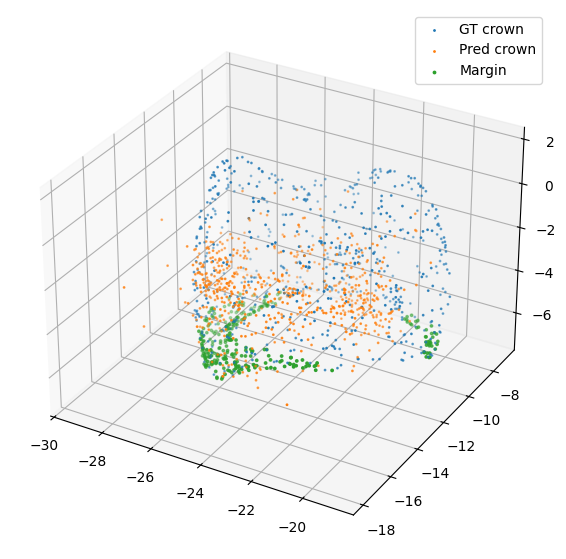

In [12]:

# Optional quick 3D scatter visualization (WORLD)
import os, numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

OUT_DIR = "/kaggle/working/infer_eval_point2mesh_scaled_v1"
sid = "000"

pred = np.load(os.path.join(OUT_DIR, f"sample_{sid}_pred_crown.npy"))
gt   = np.load(os.path.join(OUT_DIR, f"sample_{sid}_gt_crown.npy"))
mrg  = np.load(os.path.join(OUT_DIR, f"sample_{sid}_gt_margin.npy"))

pred_d = pred[::5]
gt_d   = gt[::5]
mrg_d  = mrg[::1]

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(gt_d[:,0],   gt_d[:,1],   gt_d[:,2],   s=1, label="GT crown")
ax.scatter(pred_d[:,0], pred_d[:,1], pred_d[:,2], s=1, label="Pred crown")
ax.scatter(mrg_d[:,0],  mrg_d[:,1],  mrg_d[:,2],  s=3, label="Margin")
ax.legend()
plt.show()


## 8) Export outputs (checkpoint + inference results + code)

In [13]:

%%bash
set -e
cd /kaggle/working
tar -czf point2mesh_run_outputs_rebuilt.tgz \
  runs_point2mesh_scaled_v1 \
  infer_eval_point2mesh_scaled_v1 \
  dmc_point2mesh_min/train.py \
  dmc_point2mesh_min/tools/infer_eval_fixed.py
ls -lh point2mesh_run_outputs_rebuilt.tgz


-rw-r--r-- 1 root root 2.2G Feb 22 19:51 point2mesh_run_outputs_rebuilt.tgz


In [6]:
from pathlib import Path
import shutil, os

WORK = Path("/kaggle/working")
INPUT = Path("/kaggle/input")
DST = WORK / "dmc_point2mesh_min"

# Find a valid repo inside /kaggle/input
candidates = []
for p in INPUT.rglob("train.py"):
    parent = p.parent
    if (parent / "dmc" / "dataset.py").exists() and (parent / "dmc" / "model.py").exists() and (parent / "dmc" / "losses.py").exists():
        candidates.append(parent)

if not candidates:
    raise FileNotFoundError("Couldn't find repo with train.py + dmc/{dataset,model,losses}.py under /kaggle/input")

# Prefer a path that looks like point2mesh
candidates = sorted(candidates, key=lambda x: ("point2mesh" not in str(x).lower(), len(str(x))))
SRC = candidates[0]

print("✅ Found source repo:", SRC)

# Copy to writable working directory
if DST.exists():
    shutil.rmtree(DST)
shutil.copytree(SRC, DST)

print("✅ Copied to:", DST)
print("Top-level files:", sorted([p.name for p in DST.iterdir()])[:20])
print("dmc files:", sorted([p.name for p in (DST / 'dmc').iterdir()]))

✅ Found source repo: /kaggle/input/datasets/lamiaaelfadaly/3d-crown-ai/dmc_point2mesh_min_brev_ready/dmc_point2mesh_min
✅ Copied to: /kaggle/working/dmc_point2mesh_min
Top-level files: ['README.md', 'brev', 'dmc', 'requirements.txt', 'tools', 'train.py']
dmc files: ['__init__.py', 'dataset.py', 'losses.py', 'model.py', 'ops.py']


In [7]:
from pathlib import Path
import shutil, os

WORK = Path("/kaggle/working")
INPUT = Path("/kaggle/input")
DST = WORK / "dmc_point2mesh_min"

# Find a valid repo inside /kaggle/input
candidates = []
for p in INPUT.rglob("train.py"):
    parent = p.parent
    if (parent / "dmc" / "dataset.py").exists() and (parent / "dmc" / "model.py").exists() and (parent / "dmc" / "losses.py").exists():
        candidates.append(parent)

if not candidates:
    raise FileNotFoundError("Couldn't find repo with train.py + dmc/{dataset,model,losses}.py under /kaggle/input")

# Prefer a path that looks like point2mesh
candidates = sorted(candidates, key=lambda x: ("point2mesh" not in str(x).lower(), len(str(x))))
SRC = candidates[0]

print("✅ Found source repo:", SRC)

# Copy to writable working directory
if DST.exists():
    shutil.rmtree(DST)
shutil.copytree(SRC, DST)

print("✅ Copied to:", DST)
print("Top-level files:", sorted([p.name for p in DST.iterdir()])[:20])
print("dmc files:", sorted([p.name for p in (DST / 'dmc').iterdir()]))

✅ Found source repo: /kaggle/input/datasets/lamiaaelfadaly/3d-crown-ai/dmc_point2mesh_min_brev_ready/dmc_point2mesh_min
✅ Copied to: /kaggle/working/dmc_point2mesh_min
Top-level files: ['README.md', 'brev', 'dmc', 'requirements.txt', 'tools', 'train.py']
dmc files: ['__init__.py', 'dataset.py', 'losses.py', 'model.py', 'ops.py']


In [9]:
from pathlib import Path

# Auto-find checkpoint in working or input
ckpts = list(Path("/kaggle/working").rglob("ckpt_last.pt")) + list(Path("/kaggle/input").rglob("ckpt_last.pt"))

# Fallback: epoch checkpoints
if not ckpts:
    ckpts = list(Path("/kaggle/working").rglob("ckpt_epoch_*.pt")) + list(Path("/kaggle/input").rglob("ckpt_epoch_*.pt"))

if not ckpts:
    raise FileNotFoundError("No checkpoint found (ckpt_last.pt / ckpt_epoch_*.pt). Run training or attach saved output dataset.")

# Pick latest
ckpts = sorted(ckpts, key=lambda p: p.stat().st_mtime, reverse=True)
CKPT_PATH = str(ckpts[0])

print("✅ CKPT_PATH =", CKPT_PATH)

FileNotFoundError: No checkpoint found (ckpt_last.pt / ckpt_epoch_*.pt). Run training or attach saved output dataset.

In [8]:
import os, math, random, contextlib
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader

# ---------------- Paths ----------------
CODE_ROOT = Path("/kaggle/working/dmc_point2mesh_min")
assert (CODE_ROOT / "train.py").exists(), f"Repo missing at {CODE_ROOT}"

# Adjust if your dataset path is mounted differently
DATA_CANDIDATES = [
    "/kaggle/input/datasets/lamiaaelfadaly/3d-crown-ai/dmc_data_single/dmc_data_single",
    "/kaggle/input/3d-crown-ai/dmc_data_single/dmc_data_single",
    "/kaggle/input/3d crown ai/dmc_data_single/dmc_data_single",  # rare mount naming
]
DATA_ROOT = None
for p in DATA_CANDIDATES:
    if Path(p).exists():
        DATA_ROOT = p
        break
if DATA_ROOT is None:
    # fallback auto-search for folder containing case_*
    for p in Path("/kaggle/input").rglob("dmc_data_single"):
        if any(x.name.startswith("case_") for x in p.iterdir() if x.is_dir()):
            DATA_ROOT = str(p)
            break
if DATA_ROOT is None:
    raise FileNotFoundError("Couldn't find dmc_data_single dataset folder under /kaggle/input")

OUT_DIR = Path("/kaggle/working/infer_eval_point2mesh_scaled_v1")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT =", DATA_ROOT)
print("CODE_ROOT =", CODE_ROOT)
print("CKPT_PATH =", CKPT_PATH)
print("OUT_DIR   =", OUT_DIR)

# ---------------- Imports from repo ----------------
import sys
if str(CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODE_ROOT))

from dmc.dataset import DMCCrownDataset
from dmc.model import PointToMeshNet
from dmc.losses import chamfer_l2

# ---------------- Helpers ----------------
def compute_center_scale(context, margin_gt, mode="margin", eps=1e-6):
    # context: (B,N,3), margin_gt: (B,M,3)
    if mode == "context":
        center = context.mean(dim=1, keepdim=True)
        r = (context - center).norm(dim=-1).mean(dim=1, keepdim=True)
    else:  # margin anchor (same as your fixed training)
        center = margin_gt.mean(dim=1, keepdim=True)
        r = (margin_gt - center).norm(dim=-1).mean(dim=1, keepdim=True)
    scale = r.unsqueeze(-1).clamp_min(eps)
    return center, scale

def normalize(x, center, scale):
    return (x - center) / scale

def denormalize(xn, center, scale):
    return xn * scale + center

@torch.no_grad()
def numpy_chamfer_mean(a_xyz, b_xyz):
    # a,b: torch tensors (1,N,3), (1,M,3)
    return float(chamfer_l2(a_xyz, b_xyz).detach().cpu())

def safe_model_forward(model, context_n):
    # Some versions accept crown_gt, some don't
    try:
        out = model(context_n)
    except TypeError:
        out = model(context_n, crown_gt=None)
    return out

# ---------------- Load checkpoint + model ----------------
device = "cuda" if torch.cuda.is_available() else "cpu"
ckpt = torch.load(CKPT_PATH, map_location=device)

ckpt_args = ckpt.get("args", {})
print("Checkpoint args keys:", list(ckpt_args.keys())[:20])

# Rebuild model with defaults; override from ckpt args if present
model = PointToMeshNet(
    proxy_points=1024,
    d_model=256,
    nhead=8,
    enc_layers=4,
    dec_layers=4,
    q_points=3072,
    denoise_q=128,
    grid_res=int(ckpt_args.get("grid_res", 128)),
    use_dpsr=bool(ckpt_args.get("use_dpsr", 0)),
).to(device)

model.load_state_dict(ckpt["model"], strict=True)
model.eval()

# ---------------- Dataset ----------------
use_dpsr = bool(ckpt_args.get("use_dpsr", 0))
anchor_mode = ckpt_args.get("anchor_mode", "margin")
anchor_eps = float(ckpt_args.get("anchor_eps", 1e-6))

ds = DMCCrownDataset(DATA_ROOT, require_indicator=use_dpsr)
print("Dataset size:", len(ds))

# Export first N samples (or all)
N_EXPORT = min(20, len(ds))  # change to len(ds) for all 45
indices = list(range(N_EXPORT))

ch_world = []
ch_norm = []

for i in indices:
    sample = ds[i]
    context = torch.tensor(sample["context"], dtype=torch.float32, device=device).unsqueeze(0)
    crown_gt = torch.tensor(sample["crown_gt"], dtype=torch.float32, device=device).unsqueeze(0)
    margin_gt = torch.tensor(sample["margin_gt"], dtype=torch.float32, device=device).unsqueeze(0)

    center, scale = compute_center_scale(context, margin_gt, mode=anchor_mode, eps=anchor_eps)
    context_n = normalize(context, center, scale)
    crown_gt_n = normalize(crown_gt, center, scale)
    margin_gt_n = normalize(margin_gt, center, scale)

    out = safe_model_forward(model, context_n)
    crown_pred_n = out["crown_points"]

    # to world
    crown_pred_w = denormalize(crown_pred_n, center, scale)

    # metrics
    chn = numpy_chamfer_mean(crown_pred_n, crown_gt_n)
    chw = numpy_chamfer_mean(crown_pred_w, crown_gt)
    ch_norm.append(chn)
    ch_world.append(chw)

    idx = f"{i:03d}"
    np.save(OUT_DIR / f"sample_{idx}_pred_crown.npy", crown_pred_w.squeeze(0).detach().cpu().numpy())
    np.save(OUT_DIR / f"sample_{idx}_gt_crown.npy", crown_gt.squeeze(0).detach().cpu().numpy())
    np.save(OUT_DIR / f"sample_{idx}_gt_margin.npy", margin_gt.squeeze(0).detach().cpu().numpy())

    np.save(OUT_DIR / f"sample_{idx}_pred_crown_norm.npy", crown_pred_n.squeeze(0).detach().cpu().numpy())
    np.save(OUT_DIR / f"sample_{idx}_gt_crown_norm.npy", crown_gt_n.squeeze(0).detach().cpu().numpy())
    np.save(OUT_DIR / f"sample_{idx}_gt_margin_norm.npy", margin_gt_n.squeeze(0).detach().cpu().numpy())

metrics_text = (
    "===== metrics =====\n"
    f"n={len(indices)}\n"
    f"mean_chamfer_world={float(np.mean(ch_world))}\n"
    f"mean_chamfer_norm={float(np.mean(ch_norm))}\n"
)
(OUT_DIR / "metrics.txt").write_text(metrics_text, encoding="utf-8")

print(f"✅ Saved: {OUT_DIR}")
print("n =", len(indices))
print("mean_chamfer_world:", float(np.mean(ch_world)))
print("mean_chamfer_norm :", float(np.mean(ch_norm)))
print(metrics_text)

# quick file check
pred_files = sorted(OUT_DIR.glob("sample_*_pred_crown.npy"))
print("Pred files found:", len(pred_files))
print("First 5:", [p.name for p in pred_files[:5]])

DATA_ROOT = /kaggle/input/datasets/lamiaaelfadaly/3d-crown-ai/dmc_data_single/dmc_data_single
CODE_ROOT = /kaggle/working/dmc_point2mesh_min


NameError: name 'CKPT_PATH' is not defined